# Lesson 3.4 — Higher-Order Schemes and TVD Limiters

## The Dispersion-Diffusion Dilemma

Recall from Lesson 1.6:
- First-order upwind: stable but **diffusive** (smears sharp features)
- Second-order central: accurate but **dispersive** (creates oscillations near discontinuities)

The ideal scheme: second-order accuracy in smooth regions, non-oscillatory near shocks.
This is what **TVD (Total Variation Diminishing)** schemes provide.

---

## Total Variation

The **total variation** of a discrete solution $\{u_i\}$ is:

$$TV(u) = \sum_i |u_{i+1} - u_i|$$

A scheme is TVD if $TV(u^{n+1}) \leq TV(u^n)$ — the solution cannot develop new local extrema.

**Godunov's theorem**: linear schemes that are both TVD and second-order accurate do not exist.
Solution: use **nonlinear** schemes that adapt their order depending on the local smoothness.

---

## Flux Limiters

A TVD scheme writes the face flux as:

$$F_{i+1/2} = F^{\text{upwind}}_{i+1/2} + \phi(r) \cdot (F^{\text{high}}_{i+1/2} - F^{\text{upwind}}_{i+1/2})$$

where $\phi(r)$ is the **limiter function** and $r$ is the ratio of consecutive gradients:

$$r_i = \frac{u_i - u_{i-1}}{u_{i+1} - u_i}$$

| Limiter | $\phi(r)$ | Property |
|---------|-----------|----------|
| Minmod | $\max(0, \min(1, r))$ | Most diffusive TVD |
| Van Leer | $\frac{r + |r|}{1 + |r|}$ | Smooth, second-order |
| Superbee | $\max(0, \min(2r,1), \min(r,2))$ | Least diffusive TVD |
| MC (monotonized central) | $\max(0, \min(2r, 0.5(1+r), 2))$ | Good all-round |

When $r \to 1$ (smooth region): $\phi \to 1$ → second-order accuracy.  
When $r < 0$ (local extremum): $\phi = 0$ → first-order (non-oscillatory).

---

## QUICK Scheme

QUICK (Quadratic Upstream Interpolation for Convective Kinematics, Leonard 1979) uses a
quadratic interpolation:

$$u_{i+1/2} = \frac{3}{8}u_{i+1} + \frac{6}{8}u_i - \frac{1}{8}u_{i-1} \quad (c > 0)$$

This is third-order accurate in smooth regions but not TVD — it can create overshoots near shocks.


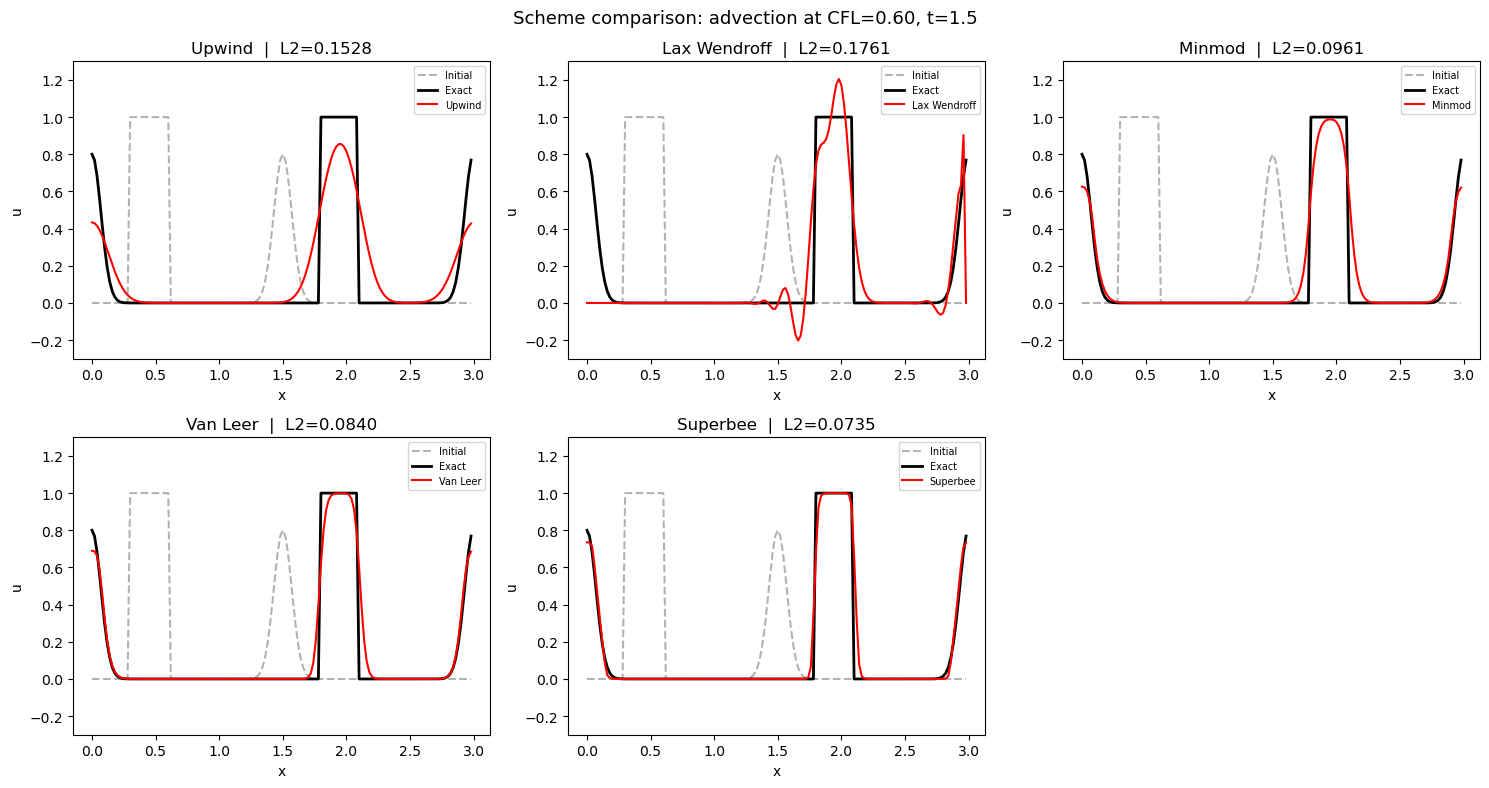

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Compare schemes on advection of a step function (discontinuity + smooth region)

def advect_scheme(u0, c, dx, dt, nt, scheme='upwind'):
    u = u0.copy()
    nu = c * dt / dx
    
    for _ in range(nt):
        u_old = u.copy()
        
        if scheme == 'upwind':
            u[1:] = u_old[1:] - nu*(u_old[1:] - u_old[:-1])
            u[0]  = u_old[0]  - nu*(u_old[0]  - u_old[-1])
            
        elif scheme == 'lax_wendroff':
            u[1:-1] = (u_old[1:-1]
                      - nu/2*(u_old[2:] - u_old[:-2])
                      + nu**2/2*(u_old[2:] - 2*u_old[1:-1] + u_old[:-2]))
            u[0]    = u_old[0]
            u[-1]   = u_old[-1]
            
        elif scheme in ('minmod', 'van_leer', 'superbee', 'mc'):
            # TVD with flux limiter
            def limiter(r, name):
                if name == 'minmod':
                    return np.maximum(0, np.minimum(1, r))
                elif name == 'van_leer':
                    return (r + np.abs(r)) / (1 + np.abs(r) + 1e-12)
                elif name == 'superbee':
                    return np.maximum(0, np.maximum(np.minimum(2*r, 1), np.minimum(r, 2)))
                elif name == 'mc':
                    return np.maximum(0, np.minimum(np.minimum(2*r, 0.5*(1+r)), 2))
            
            u_new = np.zeros_like(u_old)
            # Extended array for periodic BCs
            ue = np.concatenate([u_old[-2:], u_old, u_old[:2]])
            
            for i in range(len(u_old)):
                i_e = i + 2  # offset in extended array
                # r at right face
                denom = ue[i_e+1] - ue[i_e] + 1e-12
                r_right = (ue[i_e] - ue[i_e-1]) / denom
                phi_right = limiter(r_right, scheme)[0] if hasattr(r_right, '__len__') else limiter(np.array([r_right]), scheme)[0]
                F_right = c*(ue[i_e] + 0.5*phi_right*(1-nu)*(ue[i_e+1]-ue[i_e]))
                
                denom_l = ue[i_e] - ue[i_e-1] + 1e-12
                r_left  = (ue[i_e-1] - ue[i_e-2]) / denom_l
                phi_left = limiter(r_left, scheme)[0] if hasattr(r_left, '__len__') else limiter(np.array([r_left]), scheme)[0]
                F_left  = c*(ue[i_e-1] + 0.5*phi_left*(1-nu)*(ue[i_e]-ue[i_e-1]))
                
                u_new[i] = u_old[i] - nu*(F_right - F_left)/c
            u = u_new
    return u

# Setup: mixed initial condition (step + smooth Gaussian)
N  = 150
L  = 3.0
dx = L / N
x  = np.linspace(0, L, N, endpoint=False)
c  = 1.0
dt = 0.6 * dx / c
T  = 1.5
nt = int(T / dt)

# Step + Gaussian
u0 = np.zeros(N)
u0[(x >= 0.3) & (x <= 0.6)] = 1.0   # step
u0 += 0.8 * np.exp(-((x - 1.5)**2) / 0.01)  # Gaussian

x_exact = (x - c*T) % L
u_exact = np.zeros(N)
u_exact[(x_exact >= 0.3) & (x_exact <= 0.6)] = 1.0
u_exact += 0.8 * np.exp(-((x_exact - 1.5)**2) / 0.01)

schemes = ['upwind', 'lax_wendroff', 'minmod', 'van_leer', 'superbee']
results = {s: advect_scheme(u0, c, dx, dt, nt, s) for s in schemes}

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes_flat = axes.ravel()

for ax, scheme in zip(axes_flat, schemes):
    ax.plot(x, u0,           'k--', alpha=0.3, linewidth=1.5, label='Initial')
    ax.plot(x, u_exact,      'k-',  linewidth=2,   label='Exact')
    ax.plot(x, results[scheme], 'r-', linewidth=1.5, label=scheme.replace('_', ' ').title())
    l2 = np.sqrt(np.mean((results[scheme] - u_exact)**2))
    ax.set_title(f'{scheme.replace("_"," ").title()}  |  L2={l2:.4f}')
    ax.set_xlabel('x'); ax.set_ylabel('u')
    ax.legend(fontsize=7); ax.set_ylim(-0.3, 1.3)

axes_flat[-1].axis('off')
plt.suptitle(f'Scheme comparison: advection at CFL={c*dt/dx:.2f}, t={T}', fontsize=13)
plt.tight_layout()
plt.show()

## Sweby Diagram

Plot $\phi(r)$ vs $r$ for all limiters. A scheme is TVD if its limiter lies within the **Sweby region**:
$$\max(0, \min(2r, 1), \min(r, 2)) \geq \phi(r) \geq 0$$


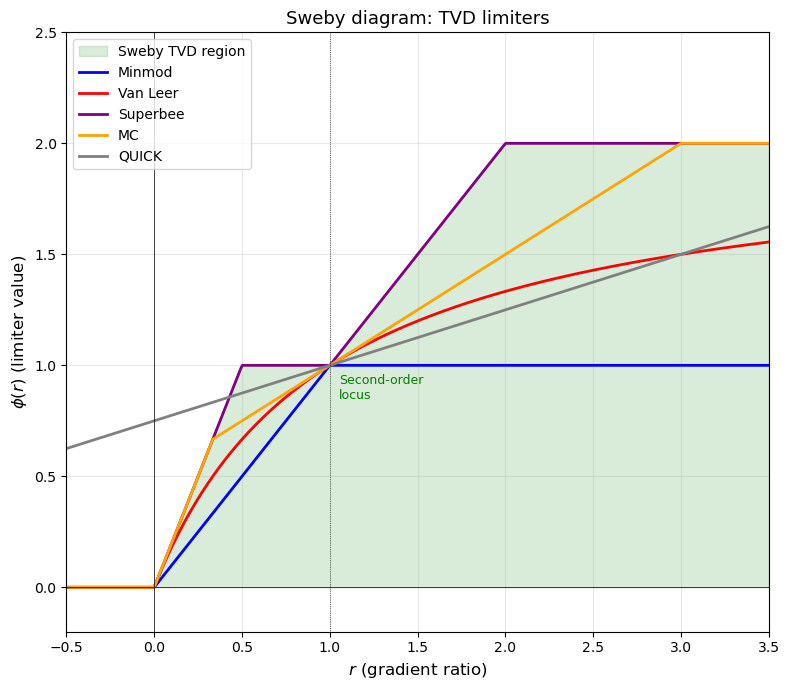

Limiters inside Sweby region → TVD (no new oscillations).
QUICK extends outside → not TVD (overshoots near discontinuities).


In [2]:
r = np.linspace(-0.5, 3.5, 500)

limiters = {
    'Minmod': np.maximum(0, np.minimum(1, r)),
    'Van Leer': (r + np.abs(r)) / (1 + np.abs(r) + 1e-12),
    'Superbee': np.maximum(0, np.maximum(np.minimum(2*r, 1), np.minimum(r, 2))),
    'MC': np.maximum(0, np.minimum(np.minimum(2*r, 0.5*(1+r)), 2)),
    'QUICK': 0.75 + 0.25*r,  # QUICK limiter (not TVD — can be outside region)
}

# Sweby region bounds
upper = np.maximum(0, np.maximum(np.minimum(2*r, 1), np.minimum(r, 2)))
lower = np.zeros_like(r)

fig, ax = plt.subplots(figsize=(8, 7))
ax.fill_between(r, lower, upper, alpha=0.15, color='green', label='Sweby TVD region')

colors = ['blue', 'red', 'purple', 'orange', 'gray']
for (name, phi), color in zip(limiters.items(), colors):
    ax.plot(r, phi, color=color, linewidth=2, label=name)

ax.axhline(0, color='k', linewidth=0.5)
ax.axvline(0, color='k', linewidth=0.5)
ax.axvline(1, color='k', linewidth=0.5, linestyle=':')
ax.set_xlabel('$r$ (gradient ratio)', fontsize=12)
ax.set_ylabel('$\\phi(r)$ (limiter value)', fontsize=12)
ax.set_title('Sweby diagram: TVD limiters', fontsize=13)
ax.legend(fontsize=10)
ax.set_xlim(-0.5, 3.5); ax.set_ylim(-0.2, 2.5)
ax.grid(True, alpha=0.3)
ax.text(1.05, 0.85, 'Second-order\nlocus', fontsize=9, color='green')
plt.tight_layout()
plt.show()

print("Limiters inside Sweby region → TVD (no new oscillations).")
print("QUICK extends outside → not TVD (overshoots near discontinuities).")

## Key Takeaways

- First-order upwind: diffusive. Second-order central/Lax-Wendroff: oscillatory near discontinuities.
- TVD schemes use **flux limiters** to be second-order in smooth regions, first-order near shocks.
- Godunov's theorem: no *linear* scheme is both second-order and TVD — limiters are nonlinear.
- Limiter choice: Minmod (most diffusive), Van Leer (smooth), Superbee (sharpest — can be over-compressive).
- In OpenFOAM: `limitedLinear` (Van Leer-like), `limitedLinearV` for vectors.

---

**Next**: Lesson 3.5 — Multigrid Methods: V-cycle, convergence acceleration.
